# Student Performance Analysis & Prediction

## Project Objective
The goal of this project is to analyze student performance data and understand how factors such as study hours, attendance, and previous scores affect final exam performance.

We also build a simple machine learning model to predict the final score of students.

## Step 1: Import Required Libraries
We import Python libraries used for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Step 2: Load the Dataset

The dataset contains information about students including their study hours, attendance, previous scores, and final exam score.

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Step 3: Explore the Dataset

We examine the structure of the dataset to understand the number of rows, columns, and data types.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Step 4: Data Cleaning

Before analysis, we check for missing values and remove incomplete data if necessary.

In [4]:
# Fill missing values for categorical columns with the most frequent value
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

# Verify no nulls remain
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


## Step 5: Data Visualization

We visualize the relationship between study hours and final exam score to see whether students who study more perform better.

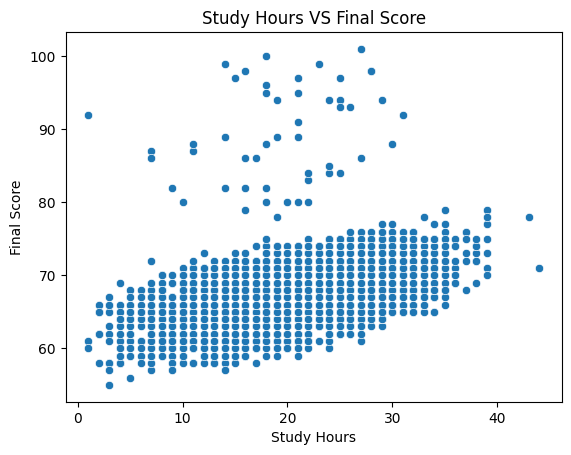

In [5]:
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Study Hours VS Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")


plt.show()

### Insight

The scatter plot shows a positive relationship between study hours and final exam score. Students who study more hours tend to achieve higher marks.

### Feature Encoding
The dataset contains categorical variables such as Parental_Involvement and Motivation_Level. Since machine learning models require numerical input, we will map these ordinal categories to numbers. We will also handle missing values in Teacher_Quality by filling them with the most frequent value (mode).

In [6]:
# 1. Handle missing values for features we want to use
# Filling with the mode (most frequent value) prevents data loss from dropna()
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Involvement'] = df['Parental_Involvement'].fillna(df['Parental_Involvement'].mode()[0])

# 2. Map Ordinal Categories (Low < Medium < High) to numbers
# This preserves the relationship that High is 'more' than Low
priority_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Parental_Involvement'] = df['Parental_Involvement'].map(priority_map)
df['Motivation_Level'] = df['Motivation_Level'].map(priority_map)
df['Teacher_Quality'] = df['Teacher_Quality'].map(priority_map)

# 3. Map Binary Categories (Yes/No) to 1 and 0
df['Internet_Access'] = df['Internet_Access'].map({'Yes': 1, 'No': 0})

print("Feature encoding complete. Categorical variables are now numerical.")

Feature encoding complete. Categorical variables are now numerical.


## Step 6: Build Machine Learning Model

We use a Linear Regression model to predict the final score of students based on study hours, attendance, and previous scores.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Prepare Training Data
We separate the input features (X) and target variable (y).

In [8]:
x = df[["Hours_Studied", "Attendance", "Previous_Scores", "Tutoring_Sessions", 
        "Parental_Involvement", "Motivation_Level", "Teacher_Quality"]]
y = df["Exam_Score"]

### Train-Test Split
We split the dataset into training data and testing data.

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

### Model Training
We train the Linear Regression model using the training dataset.

In [10]:
model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 7: Model Prediction
The trained model is used to predict the final exam score for the test dataset.

In [11]:
predictions = model.predict(x_test)

comparison = pd.DataFrame({
    "Actual Score": y_test,
    "Predicted Score": predictions
})

comparison.head()

,Actual Score,Predicted Score
4103,66,66.121153
4451,67,67.753160
5223,64,62.773272
898,69,66.757956
5302,72,72.379505


## Step 8: Model Evaluation

We evaluate the model performance using R² score.

In [12]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("Model Accuracy: {:.2f}%".format(score*100))

Model Accuracy: 74.17%


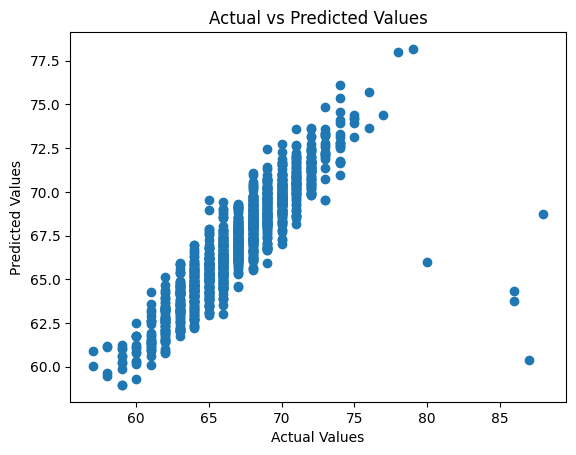

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

### Actual vs Predicted Visualization

The scatter plot below compares the actual values with the predicted values generated by the model. If the model performs well, the points should lie close to a straight line.

## Conclusion

This project analyzed the relationship between study habits and academic performance.

Key findings:
- Students who study more hours tend to achieve higher scores.
- Attendance also influences student performance.
- A Linear Regression model was able to predict student scores based on these factors.

This demonstrates how data analysis and machine learning can help understand patterns in educational data.

### Final Model Performance: 
The Linear Regression model achieved an R² score of 73.62%, indicating a strong correlation between student engagement (attendance/study hours) and exam results.